# Exploratory Data Analysis

In [ ]:
import pandas as pd

gym_data = pd.read_csv('/content/gym_churn_us.csv')
gym_data.head(10)

,gender,Near_Location,Partner,Promo_friends,Phone,Contract_period,Group_visits,Age,Avg_additional_charges_total,Month_to_end_contract,Lifetime,Avg_class_frequency_total,Avg_class_frequency_current_month,Churn
0,1,1,1,1,0,6,1,29,14.227470,5.0,3,0.020398,0.000000,0
1,0,1,0,0,1,12,1,31,113.202938,12.0,7,1.922936,1.910244,0
2,0,1,1,0,1,1,0,28,129.448479,1.0,2,1.859098,1.736502,0
3,0,1,1,1,1,12,1,33,62.669863,12.0,2,3.205633,3.357215,0
4,1,1,1,1,1,1,0,26,198.362265,1.0,3,1.113884,1.120078,0
5,1,1,0,0,1,1,1,34,450.743960,1.0,3,2.623477,2.637007,0
6,1,1,1,1,0,6,1,32,94.266389,6.0,2,1.138941,1.277242,0
7,0,1,0,0,1,1,0,30,217.786641,1.0,0,1.213502,1.049387,1
8,1,1,1,1,1,1,1,23,45.409909,1.0,1,1.106239,1.059333,0
9,0,1,0,0,1,1,0,31,65.310836,1.0,11,1.810852,1.951368,0


In [ ]:
gym_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 14 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   gender                             4000 non-null   int64  
 1   Near_Location                      4000 non-null   int64  
 2   Partner                            4000 non-null   int64  
 3   Promo_friends                      4000 non-null   int64  
 4   Phone                              4000 non-null   int64  
 5   Contract_period                    4000 non-null   int64  
 6   Group_visits                       4000 non-null   int64  
 7   Age                                4000 non-null   int64  
 8   Avg_additional_charges_total       4000 non-null   float64
 9   Month_to_end_contract              4000 non-null   float64
 10  Lifetime                           4000 non-null   int64  
 11  Avg_class_frequency_total          4000 non-null   float

In [ ]:
print(gym_data.shape)

(4000, 14)


In [ ]:
print(gym_data.isnull().sum())

gender                               0
Near_Location                        0
Partner                              0
Promo_friends                        0
Phone                                0
Contract_period                      0
Group_visits                         0
Age                                  0
Avg_additional_charges_total         0
Month_to_end_contract                0
Lifetime                             0
Avg_class_frequency_total            0
Avg_class_frequency_current_month    0
Churn                                0
dtype: int64


In [ ]:
print(gym_data.duplicated().sum())

0


In [ ]:
gym_data.describe().T

,count,mean,std,min,25%,50%,75%,max
gender,4000.0,0.510250,0.499957,0.000000,0.000000,1.000000,1.000000,1.000000
Near_Location,4000.0,0.845250,0.361711,0.000000,1.000000,1.000000,1.000000,1.000000
Partner,4000.0,0.486750,0.499887,0.000000,0.000000,0.000000,1.000000,1.000000
Promo_friends,4000.0,0.308500,0.461932,0.000000,0.000000,0.000000,1.000000,1.000000
Phone,4000.0,0.903500,0.295313,0.000000,1.000000,1.000000,1.000000,1.000000
Contract_period,4000.0,4.681250,4.549706,1.000000,1.000000,1.000000,6.000000,12.000000
Group_visits,4000.0,0.412250,0.492301,0.000000,0.000000,0.000000,1.000000,1.000000
Age,4000.0,29.184250,3.258367,18.000000,27.000000,29.000000,31.000000,41.000000
Avg_additional_charges_total,4000.0,146.943728,96.355602,0.148205,68.868830,136.220159,210.949625,552.590740
Month_to_end_contract,4000.0,4.322750,4.191297,1.000000,1.000000,1.000000,6.000000,12.000000


*Descriptive Summary Key Insights*
* Gender mean > 0.5, indicating roughly equal distribution with slightly more males;
* Near_location with a mean of 0.85, meaning 85% of members live nearby of the gym location;
* Almost 49% of the users are employees of a partner company (`Partner` mean ~ 0.49), who may have discount;
* Around 31% of the users originally signed up through a "bring a friend" offer (`Promo_friends` mean ~ 0.31);
* 90% of the users provided their phone numbers (`Phone` mean ~ 0.90);
* The average contract period is around 4.68 months, but the median is 1 month, indicating a large concentration of short-term contracts;
* Around 41% of users participate in group visits (`Group_visits` mean ~ 0.41);
* The average age is around 29 years old, ranging from 18 to 41;
* Average additional charges are roughly 147, but there's significant variance (std ~ 96);
* The average lifetime of a member is 3.72 months;
* Users take around 1.88 classes per week during their membership lifetime on average (`Avg_class_frequency_total`);
* The overall churn rate for this dataset is roughly 26.5% (`Churn` mean ~ 0.265).

## Data Distribution

In [ ]:
gym_data['Churn'].value_counts(normalize=True)

,proportion
Churn,
0,0.73475
1,0.26525


<Axes: xlabel='Churn', ylabel='count'>

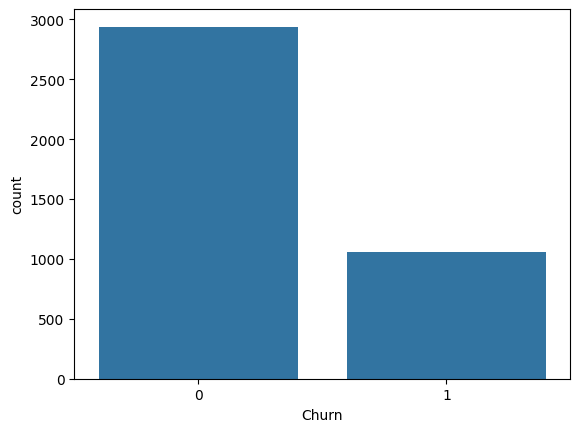

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='Churn', data=gym_data)

Churn rate in total is around 26.5%

In [ ]:
# 区分变量类型
binary_cols = ['gender','Near_Location','Partner','Promo_friends','Phone','Group_visits']
cont_cols = ['Age','Avg_additional_charges_total','Month_to_end_contract',
             'Lifetime','Avg_class_frequency_total','Avg_class_frequency_current_month']
# Contract_period 是准分类(1/6/12),单独处理

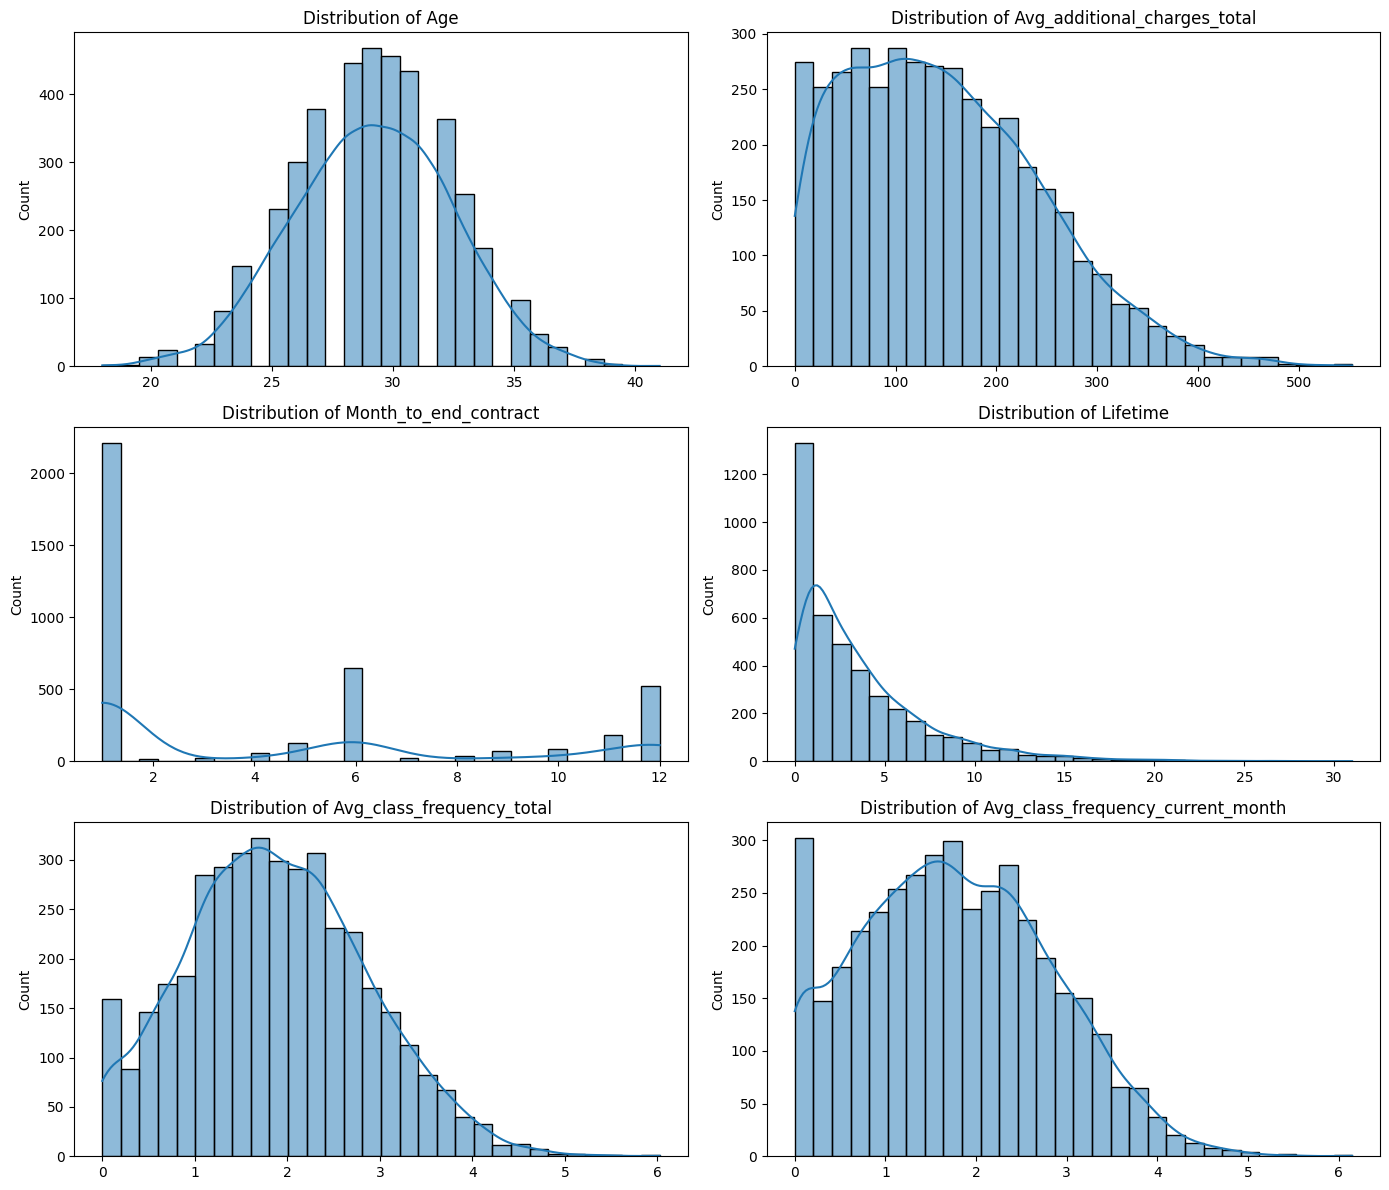

In [ ]:
# 连续变量用直方图看分布，并添加KDE曲线
fig, axes = plt.subplots(3, 2, figsize=(14, 12))
for ax, col in zip(axes.flat, cont_cols):
    sns.histplot(gym_data[col], bins=30, kde=True, ax=ax)
    ax.set_title(f'Distribution of {col}')
    ax.set_xlabel('')

plt.tight_layout()
plt.show()

*Analysis on Histogram Charts*

Based on the distributions of the continuous variables:
* **Age**: The distribution is approximately normal (bell-shaped), with most members concentrated around 28 to 32 years old.
* **Avg_additional_charges_total**: The distribution is heavily right-skewed. Most members spend a relatively small amount on extra services, while a few spend significantly more.
* **Month_to_end_contract**: Shows distinct peaks, likely corresponding to standard contract lengths (e.g., 1, 6, and 12 months). A large portion of users have only 1 month left.
* **Lifetime**: This is also right-skewed. The majority of members have been with the gym for a short period (0-5 months), with the number of members steadily decreasing as the lifetime increases.
* **Avg_class_frequency_total**: Roughly normally distributed, with most members attending between 1 and 3 classes per week on average over their entire membership.
* **Avg_class_frequency_current_month**: Similar distribution to the total average frequency, indicating consistent attendance behavior, centered around 1 to 3 classes per week recently.

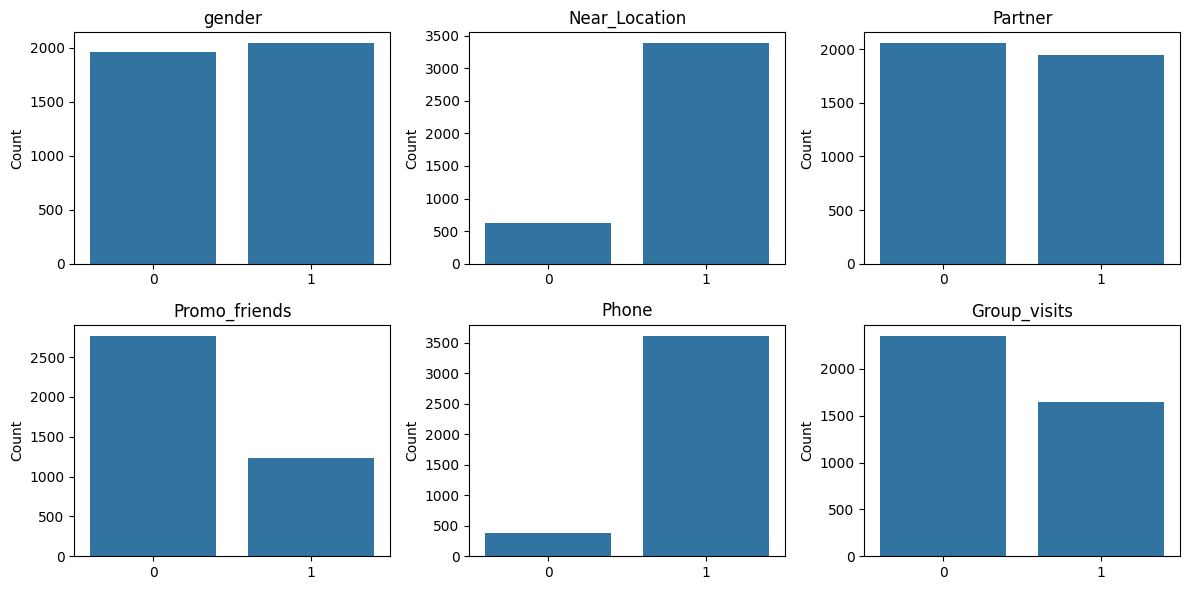

In [ ]:
# 二元变量用计数图看占比
fig, axes = plt.subplots(2, 3, figsize=(12, 6))

for ax, col in zip(axes.flat, binary_cols):
    sns.countplot(x=col, data=gym_data, ax=ax)
    ax.set_title(col)
    ax.set_xlabel("")
    ax.set_ylabel("Count")

plt.tight_layout()
plt.show()

*Analysis on Binary Variables Charts*

Based on the count plots for the binary variables:
* **gender**: The distribution is nearly perfectly balanced between the two genders.
* **Near_Location**: The vast majority of members live or work near the gym location.
* **Partner**: Members are almost evenly split between those who are employees of a partner company and those who are not.
* **Promo_friends**: Most members did not sign up through the "bring a friend" promotion, though 31% did.
* **Phone**: Almost all members provided a phone number when signing up.
* **Group_visits**: More members prefer individual workouts, but a substantial portion (around 40%) participate in group fitness classes.

## Relationship and Correlation Between Variables and Churn Rate

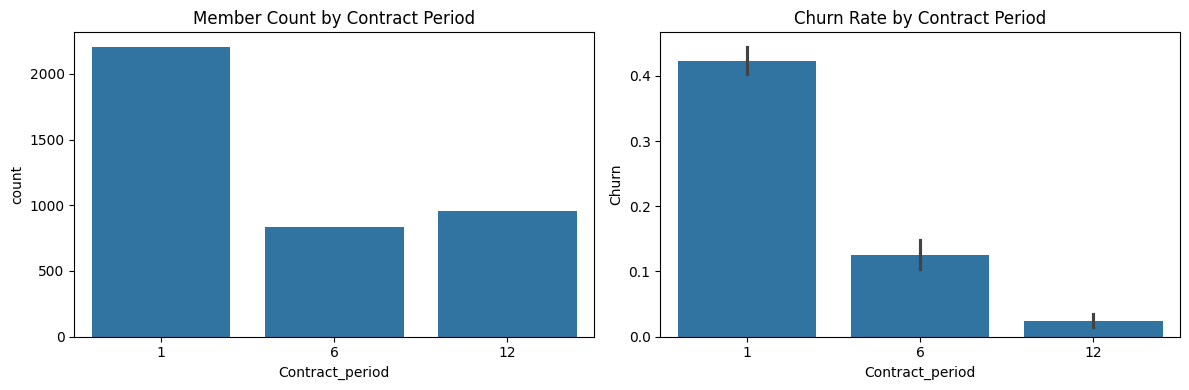

In [ ]:
# 会员类型（月度，半年，年度）人数分布 + 各类型的平均流失率
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.countplot(x='Contract_period', data=gym_data, ax=axes[0])
axes[0].set_title('Member Count by Contract Period')
sns.barplot(x='Contract_period', y='Churn', data=gym_data, ax=axes[1])
axes[1].set_title('Churn Rate by Contract Period')
plt.tight_layout(); plt.show()

* **Contract_period**: The majority of members are on 1-month contracts, followed by 12-month and then 6-month contracts. Notably, there is a strong inverse relationship between contract length and churn: members with 1-month contracts have the highest churn rate by far, while those with 6-month and 12-month contracts have significantly lower churn rates. This suggests that longer-term commitments strongly correlate with higher retention.

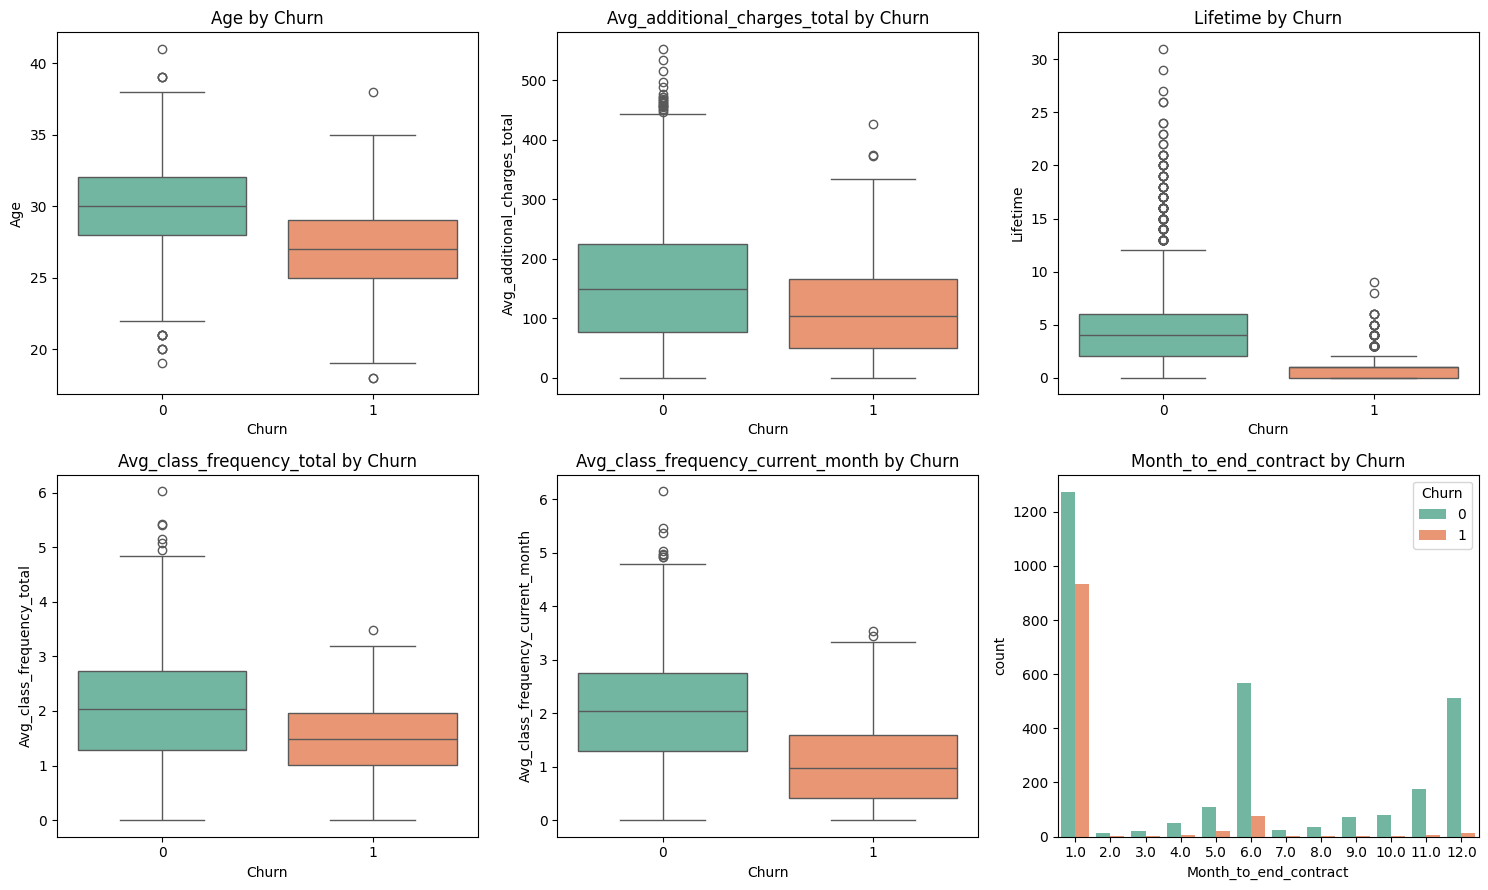

In [ ]:
# 连续变量按churn分组看分布差异(箱线图)
plot_cont_cols = ['Age', 'Avg_additional_charges_total', 'Lifetime', 'Avg_class_frequency_total', 'Avg_class_frequency_current_month']

fig, axes = plt.subplots(2, 3, figsize=(15, 9))

# Boxplots for the strictly continuous variables
for ax, col in zip(axes.flat[:5], plot_cont_cols):
    sns.boxplot(x='Churn', y=col, data=gym_data, ax=ax, hue='Churn', palette='Set2', legend=False)
    ax.set_title(f'{col} by Churn')

# Countplot for Month_to_end_contract (quasi-categorical)
sns.countplot(x='Month_to_end_contract', hue='Churn', data=gym_data, ax=axes.flat[5], palette='Set2')
axes.flat[5].set_title('Month_to_end_contract by Churn')

plt.tight_layout()
plt.show()

*Analysis on Continuous Variables & Contract Months by Churn*

Based on the charts:
* **Age**: Retained members (Churn=0) are slightly older on average compared to those who churn (Churn=1).
* **Avg_additional_charges_total**: Members who stay generally spend more on extra gym services (like the cafe or massages).
* **Lifetime**: There is a stark difference here. Churned members typically have a very short lifetime (often leaving within the first 1-2 months). Retained members have a much longer and wider lifetime distribution.
* **Avg_class_frequency_total**: Retained members have a higher overall average weekly attendance.
* **Avg_class_frequency_current_month**: This metric shows a sharp drop for churned members, <u>*indicating they attend significantly fewer classes in the month right before they drop out*</u>.
* **Month_to_end_contract**: The count plot clearly shows that churn almost exclusively happens among members who have only 1 month left on their contract. Members with 6 or 12 months remaining have extremely low churn rates.

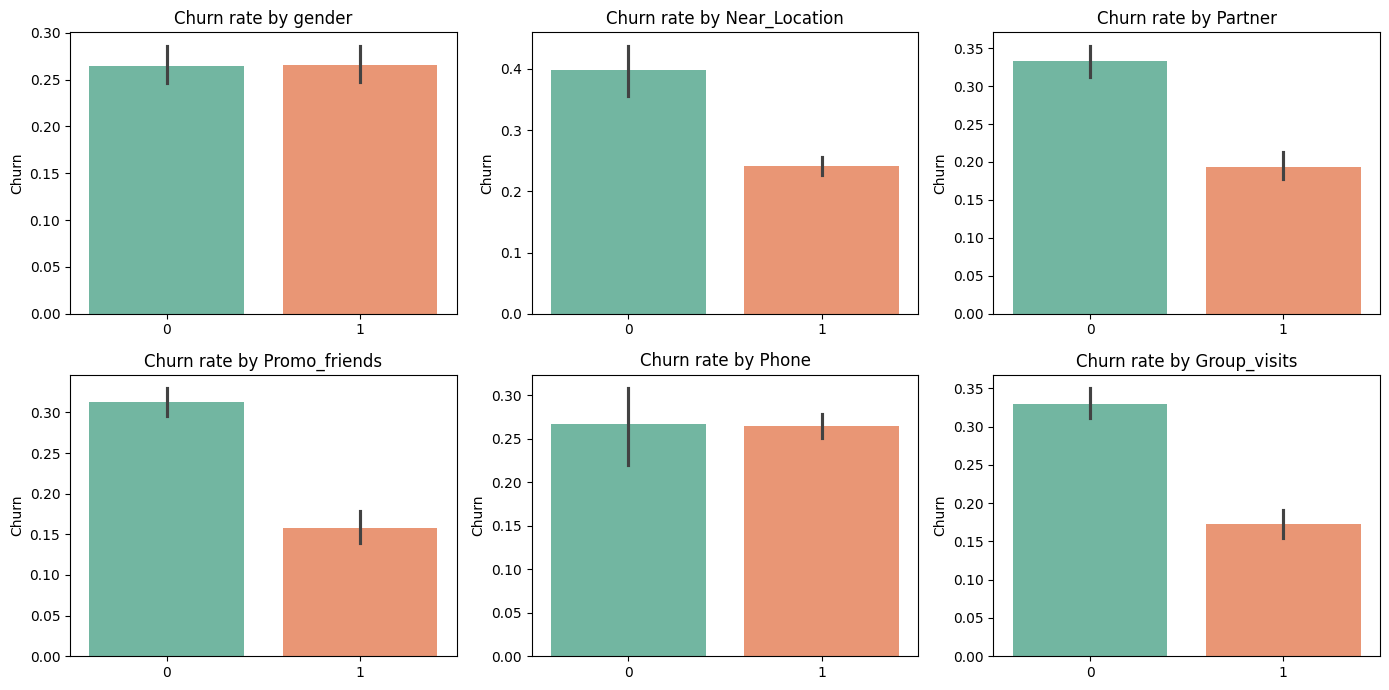

In [ ]:
# 二元变量:看每个类别的流失率(Contract_period为三元变量，已在前面单独处理)
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for ax, col in zip(axes.flat, binary_cols):
    sns.barplot(x=col, y='Churn', data=gym_data, ax=ax, palette='Set2', hue=col, legend=False)
    ax.set_title(f'Churn rate by {col}')
    ax.set_xlabel('')

plt.tight_layout() #防止图重叠
plt.show()

*Analysis on Binary Variables vs. Churn Rate*

Based on the bar plots showing the churn rate for each binary feature:
* **gender**: The churn rate is practically identical for both genders, indicating it is not a predictive factor for churn.
* **Near_Location**: Members who live or work further from the gym have a noticeably higher churn rate than those located nearby.
* **Partner**: Employees of partner companies have a significantly lower churn rate, likely due to corporate discounts, financial incentives, or shared commitments.
* **Promo_friends**: Members who signed up through the "bring a friend" promo show a lower churn rate, suggesting that having a workout buddy improves long-term retention.
* **Phone**: Whether a member provided a phone number or not has almost no impact on their likelihood to churn.
* **Group_visits**: Participating in group fitness classes is associated with a substantially lower churn rate compared to members who only work out individually.

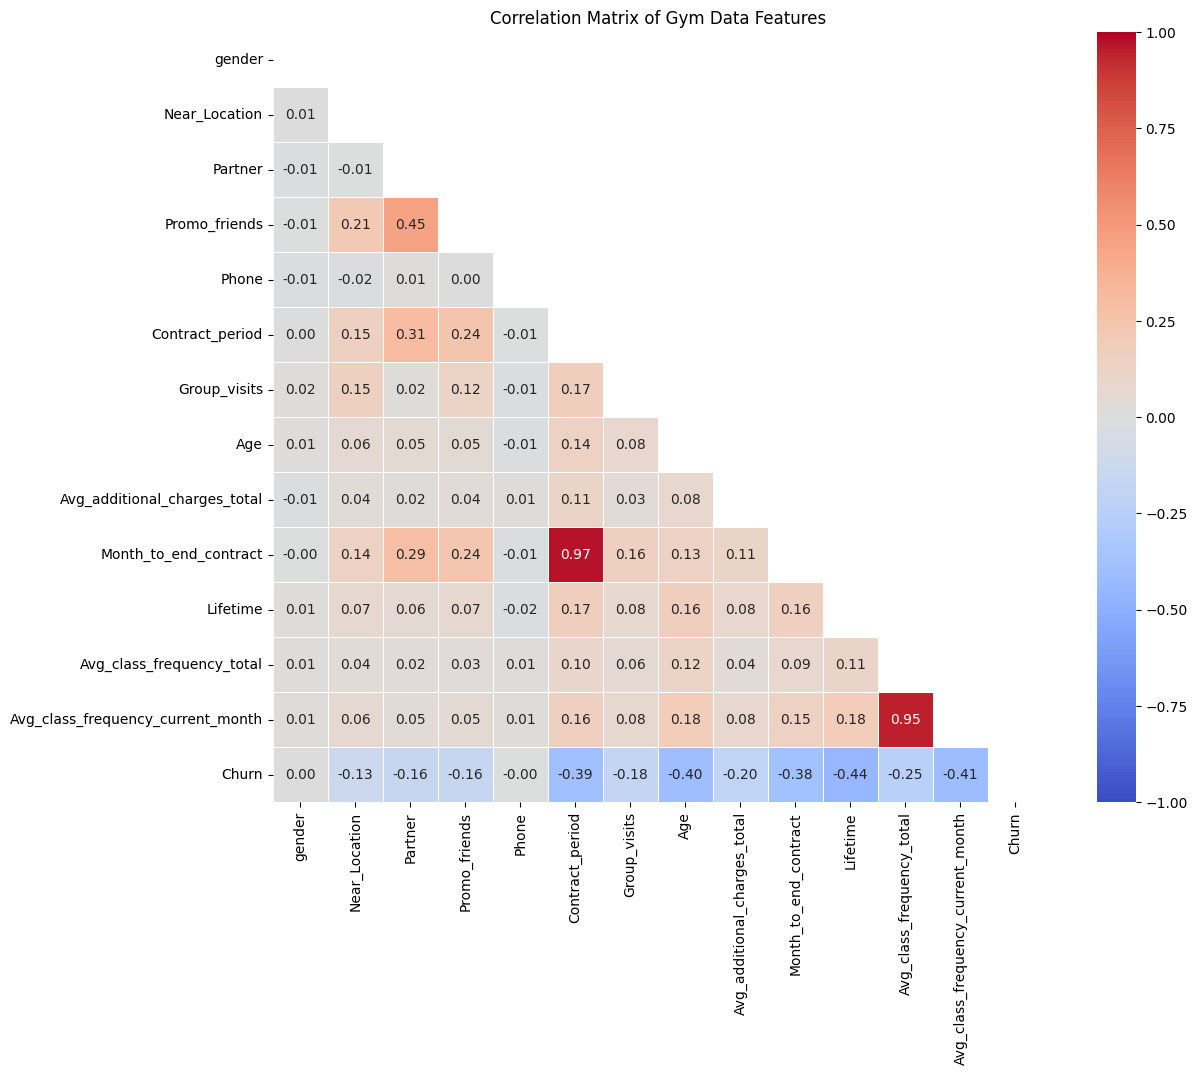

In [ ]:
# 相关性热力图
# corr(A, B) = corr(B, A)，上三角和下三角的信息是重复的，已隐藏
import numpy as np

# Calculate and plot the correlation matrix
plt.figure(figsize=(14, 10))
correlation_matrix = gym_data.corr()

# Create a mask for the upper triangle
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))

# Create a heatmap with the mask and explicit value ranges
sns.heatmap(correlation_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            vmin=-1, vmax=1, center=0, square=True, linewidths=0.5)
plt.title('Correlation Matrix of Gym Data Features')
plt.show()

*Analysis on Correlation Matrix*

Based on the heatmap:
* **Strong Positive Correlations (Multicollinearity):**
  * `Contract_period` and `Month_to_end_contract` are highly correlated (0.97). This makes perfect sense, as they essentially measure the same thing for many users (especially those on new or standard contracts).
  * `Avg_class_frequency_current_month` and `Avg_class_frequency_total` are also highly correlated (0.95).
  * *Note: If we build predictive models, we might need to drop one from each of these highly correlated pairs to avoid multicollinearity issues.*
* **Correlations with `Churn` (Target Variable):**
  * `Lifetime` (-0.44): The longer someone has been a member, the less likely they are to churn. This is the strongest negative correlation with churn.
  * `Avg_class_frequency_current_month` (-0.41): A sharp drop in recent attendance is a strong indicator of churn.
  * `Age` (-0.40): Older members in this dataset are less likely to churn.
  * `Contract_period` (-0.39) & `Month_to_end_contract` (-0.38): Longer contracts mean lower churn.
  * Variables like `gender` and `Phone` have almost zero correlation with `Churn`, meaning they aren't useful predictors on their own.

In [ ]:
# VIF 量化共线性
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

# 提取特征并添加常数项
X = add_constant(gym_data.drop(columns='Churn'))

# 计算VIF
vif_data = pd.DataFrame()
vif_data["feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

# 过滤掉常数项，按VIF值降序排列，并保留两位小数
vif_data = vif_data[vif_data['feature'] != 'const'].sort_values('VIF', ascending=False).round(2)

# 显示结果
display(vif_data)

,feature,VIF
6,Contract_period,19.18
10,Month_to_end_contract,18.88
13,Avg_class_frequency_current_month,12.52
12,Avg_class_frequency_total,11.95
3,Partner,1.36
4,Promo_friends,1.35
11,Lifetime,1.11
2,Near_Location,1.10
8,Age,1.09
7,Group_visits,1.06


*Analysis on VIF (Variance Inflation Factor)*

Based on the VIF results, we can quantify the multicollinearity observed in the correlation matrix:
* **High Collinearity (VIF > 10)**:
  * `Contract_period` (19.18) and `Month_to_end_contract` (18.88): These two variables are highly collinear, which aligns with their 0.97 correlation coefficient. They essentially represent the same temporal aspect of the user's contract.
  * `Avg_class_frequency_current_month` (12.52) and `Avg_class_frequency_total` (11.95): These are also highly collinear, confirming that recent attendance is strongly tied to historical average attendance.
* **Low/No Collinearity (VIF ~ 1)**:
  * All other variables have VIF scores close to 1 (between 1.00 and 1.36), indicating they do not suffer from significant multicollinearity.

*Recommendation*:
To build a robust predictive model (e.g., Logistic Regression) and ensure stable feature coefficients, we should remove one variable from each highly correlated pair to eliminate multicollinearity. For example, we could drop `Month_to_end_contract` and `Avg_class_frequency_total` before feature scaling and model training.

# Logistic Regression

## Model Performance

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 1. Define features (X) and target (y)
# Drop highly collinear features identified via VIF
cols_to_drop = ['Churn', 'Month_to_end_contract', 'Avg_class_frequency_total']
X = gym_data.drop(columns=cols_to_drop)
y = gym_data['Churn']

# 2. Split the data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 3. Standardize the features
# Logistic regression is sensitive to feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4. Initialize and train the Logistic Regression model
log_reg = LogisticRegression(random_state=42)
log_reg.fit(X_train_scaled, y_train)

# 5. Make predictions on the test set
y_pred = log_reg.predict(X_test_scaled)

# 6. Evaluate the model
print("Accuracy Score:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy Score: 0.91625

Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.95      0.94       588
           1       0.86      0.82      0.84       212

    accuracy                           0.92       800
   macro avg       0.90      0.89      0.89       800
weighted avg       0.92      0.92      0.92       800


Confusion Matrix:
 [[559  29]
 [ 38 174]]


*Analysis on Logistic Regression Model Performance*

Based on the evaluation metrics:
* **Overall Accuracy (91.6%)**: The model correctly predicts the outcome for roughly 92% of all members. While high accuracy alone can sometimes be misleading for an imbalanced dataset (since ~73.5% of users naturally stay), so we must look at class-specific metrics.
* **Precision & Recall for Churn (Class 1)**:
  * **Recall (0.82)**: The model successfully catches 82% of all members who actually churned (174 out of 212). This is a strong result for a minority class.
  * **Precision (0.86)**: When the model flags a user as a churn risk, it is correct 86% of the time.
  * **F1-Score (0.84)**: This harmonic mean shows a very healthy balance between Precision and Recall.
* **Confusion Matrix Breakdown**:
  * **True Negatives (559)**: Correctly predicted to stay.
  * **True Positives (174)**: Correctly predicted to churn.
  * **False Positives (29)**: The model predicted they would churn, but they stayed. In a business context, this is a minor error (e.g., wasting a small retention discount on someone who wasn't leaving).
  * **False Negatives (38)**: The model predicted they would stay, but they actually churned. These are the "missed opportunities" where the gym loses a customer because they weren't flagged for intervention.

*Conclusion*: The Logistic Regression model performs exceptionally well. It proves highly capable of identifying at-risk members with minimal false alarms, making it a reliable tool for targeted retention campaigns.

### Confusion Matrix Structure

| Actual / Predicted | Predicted 0: No Churn | Predicted 1: Churn |
|---|---:|---:|
| **Actual 0: No Churn** | **TN** | **FP** |
| **Actual 1: Churn** | **FN** | **TP** |

- **TN - True Negative**: 实际没流失，预测没流失  
- **FP - False Positive**: 实际没流失，误判为流失  
- **FN - False Negative**: 实际流失，误判为没流失  
- **TP - True Positive**: 实际流失，预测流失  


$Precision = \frac{TP}{TP + FP}$

$Recall = \frac{TP}{TP + FN}$

### Business Interpretation of Confusion Matrix

In the context of churn prediction, the types of errors our model makes have different business costs:
* **False Negatives (Predicted Stay, Actually Churned):** This is the **costliest error**. These are at-risk members who slip through the cracks and receive no retention intervention. Our current model has 38 False Negatives (with a recall of 82% for the churn class).
* **False Positives (Predicted Churn, Actually Stayed):** This error is less costly. It simply means we might waste some marketing or retention budget (like offering a discount) on a member who wasn't going to leave anyway.

Because missing a churner is expensive, we might want to prioritize **Recall** over Precision.

## Model Explanation (Coefficient & Odds Ratio)

In [ ]:
import numpy as np
import pandas as pd

# Re-initialize with max_iter=1000 to ensure convergence
# 逻辑回归训练时需要通过优化算法寻找最佳系数，如果默认迭代次数不够，可能会出现 convergence warning。设置 max_iter=1000 是为了确保模型更容易收敛。
log_reg = LogisticRegression(random_state=42, max_iter=1000)
log_reg.fit(X_train_scaled, y_train)

# Coefficient Interpretation
# Build a DataFrame with feature names, standardized coefficients, and odds ratios
feature_names = X.columns
coefficients = log_reg.coef_[0]

coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients,
    'Odds_Ratio': np.exp(coefficients)
}).sort_values(by='Coefficient', ascending=False)

# Explanation:
# Because features are standardized, the magnitude of 'Coefficient' tells us the relative importance.
# Odds Ratio > 1: An increase in this feature RAISES the odds of the member churning.
# Odds Ratio < 1: An increase in this feature LOWERS the odds of the member churning.
print("Feature Coefficients and Odds Ratios:")
display(coef_df)

Feature Coefficients and Odds Ratios:


,Feature,Coefficient,Odds_Ratio
0,gender,0.033697,1.034272
2,Partner,-0.029832,0.970609
1,Near_Location,-0.063870,0.938127
4,Phone,-0.078310,0.924678
3,Promo_friends,-0.203771,0.815649
6,Group_visits,-0.364891,0.694272
8,Avg_additional_charges_total,-0.587696,0.555606
7,Age,-1.190236,0.304149
10,Avg_class_frequency_current_month,-1.268760,0.281180
5,Contract_period,-1.389061,0.249309


*Analysis on Feature Coefficients and Odds Ratios*

Because we standardized the features before training, we can compare the magnitude of the coefficients directly. The **Odds Ratio** (exp(coef)) makes this even easier to interpret: an Odds Ratio < 1 means the feature reduces churn (promotes retention), while > 1 increases churn risk.

* **Strongest Retention Drivers (Odds Ratio << 1)**:
  * **`Lifetime` (OR: 0.022)**: By far the strongest predictor. As a member's lifetime increases, their odds of churning plummet. If they survive the first few months, they are highly likely to stay.
  * **`Contract_period` (OR: 0.249)**: Longer-term contracts drastically reduce churn odds compared to short-term (1-month) contracts.
  * **`Avg_class_frequency_current_month` (OR: 0.281)**: Recent high engagement is a massive protective factor. A sudden drop in recent attendance is a huge red flag.
  * **`Age` (OR: 0.304)**: Older members in this specific dataset tend to be significantly more loyal and stable in their memberships.
* **Moderate Retention Drivers**:
  * **`Avg_additional_charges_total` (OR: 0.556)**: Spending money on secondary services (cafe, massages) indicates a higher investment in the gym ecosystem, lowering churn.
  * **`Group_visits` (OR: 0.694) & `Promo_friends` (OR: 0.816)**: Social factors like group classes and joining with a friend moderately improve retention.
* **Non-Predictive Features (Odds Ratio ~ 1)**:
  * **`gender` (1.03), `Partner` (0.97), `Near_Location` (0.94), `Phone` (0.92)**: These features have coefficients very close to 0 and Odds Ratios close to 1. When accounting for other behavioral metrics like attendance and contract length, demographic details like gender or whether they live nearby lose their predictive power.

*Business Takeaway*: Retention campaigns should focus heavily on the first few months (`Lifetime`), encouraging members to sign longer `Contract_period`s, and closely monitoring `Avg_class_frequency_current_month` to intervene the moment attendance drops.

## ROC-AUC Evaluation
For an imbalanced dataset (~26.5% churn), Accuracy can be misleading (a model predicting '0' for everyone would still be 73.5% accurate). **ROC-AUC (Area Under the Receiver Operating Characteristic Curve)** is more appropriate because it measures the model's ability to distinguish between the two classes across *all* possible classification thresholds, independent of the class distribution.

ROC-AUC Score: 0.9668


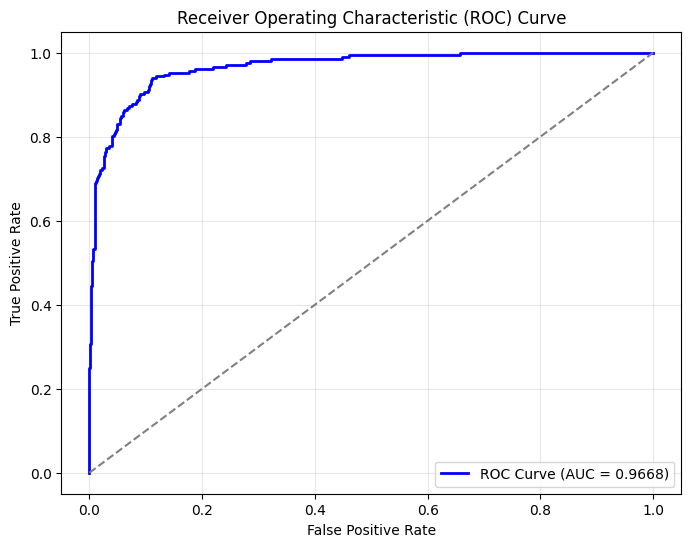

In [ ]:
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt

# Compute predicted probabilities for the positive class (Churn = 1)
y_pred_proba = log_reg.predict_proba(X_test_scaled)[:, 1]

# Calculate and print ROC-AUC score
roc_auc = roc_auc_score(y_test, y_pred_proba)
print(f"ROC-AUC Score: {roc_auc:.4f}")

# Plot the ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC Curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()

*Analysis on ROC-AUC Evaluation*

Based on the ROC-AUC score and the plotted curve:
* **Outstanding Discriminative Power (AUC = 0.9668)**: The Area Under the Curve (AUC) is exceptionally high. This means there is a 96.68% probability that the model will assign a higher churn risk score to a randomly chosen churned member than to a randomly chosen retained member. *模型可以在较低误报率下抓住大部分真实流失会员*
* **Curve Shape**: The ROC curve steeply hugs the top-left corner of the plot. This visualizes the model's ability to achieve a very high True Positive Rate (Recall) while simultaneously maintaining a very low False Positive Rate.
* **Robustness to Imbalance**: In datasets where one class dominates (like the ~73.5% retention rate here), simple accuracy can be misleading. The high ROC-AUC confirms that the model's performance is legitimate and that it has effectively learned the underlying patterns of churn, rather than just guessing the majority class.

*Business Takeaway*: The model is highly reliable across different thresholds. Because the curve is so steep, we have excellent flexibility to lower the decision threshold (to catch more "at-risk" members) without triggering an overwhelming wave of false alarms.

## Threshold Tuning & Precision-Recall Tradeoff
By lowering the classification threshold from the default 0.5 to 0.35, we make the model more "sensitive" to predicting churn. This **raises recall** (catches more at-risk members) at the cost of **more false positives** (lower precision). The optimal threshold depends entirely on the business tradeoff between the cost of a retention campaign and the lifetime value of saving a member.

In [ ]:
# Threshold tuning to demonstrate the precision-recall tradeoff
custom_threshold = 0.35

# Apply the new threshold to the predicted probabilities
y_pred_custom = (y_pred_proba >= custom_threshold).astype(int)

print(f"--- Evaluation with Custom Threshold = {custom_threshold} ---")
print("\nNew Confusion Matrix:\n", confusion_matrix(y_test, y_pred_custom))
print("\nNew Classification Report:\n", classification_report(y_test, y_pred_custom))

--- Evaluation with Custom Threshold = 0.35 ---

New Confusion Matrix:
 [[540  48]
 [ 26 186]]

New Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.92      0.94       588
           1       0.79      0.88      0.83       212

    accuracy                           0.91       800
   macro avg       0.87      0.90      0.88       800
weighted avg       0.91      0.91      0.91       800



*Analysis on Threshold Tuning (Custom Threshold = 0.35)*

By lowering the threshold from the default 0.5 to 0.35, we observe the expected precision-recall tradeoff:

*   **Higher Recall (0.82 -> 0.88)**: The model now successfully identifies 88% (186 out of 212) of the members who actually churned. The number of **False Negatives** (missed churners) dropped significantly from 38 down to 26.
*   **Lower Precision (0.86 -> 0.79)**: Because the model is more sensitive, it flags more members overall. When it predicts someone will churn, it is now correct 79% of the time, down from 86%. The number of **False Positives** (false alarms) increased from 29 to 48.
*   **Overall Accuracy (91.6% -> 90.7%)**: There is a slight drop in overall accuracy, but this is an acceptable tradeoff.

*Business Takeaway*: Lowering the threshold to 0.35 is highly beneficial if the cost of an intervention (e.g., sending a 10% discount email) is low, but the cost of losing a customer is high. We caught 12 more churners at the expense of 19 more false alarms. For a subscription business, saving those extra 12 members typically outweighs the minor cost of giving 19 stable members an unneeded perk.